In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm  # For InceptionResNetV2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import os

# Set device (use GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Data transforms (InceptionResNetV2 uses 299x299 input)
train_transform = transforms.Compose([
    transforms.Resize(342),
    transforms.CenterCrop(299),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(342),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset (change path)
dataset_path = '/home/rifat-cou/Documents/Project/Dataset_Raw'  # Folder with class subfolders
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

# Split into train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply val transform to val set (no augmentation)
val_dataset.dataset.transform = val_transform

# Data loaders (batch 16 due to model size; ~4GB VRAM usage, reduce to 8 if OOM)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4)

# Class names
class_names = full_dataset.classes
print(f"Classes: {class_names}")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Classes: ['Chikenpox', 'Cowpox', 'Measles', 'MonkeyPox', 'Normal']
Train samples: 2088, Val samples: 523


In [3]:
# Load pre-trained InceptionResNetV2 from timm
model = timm.create_model('inception_resnet_v2', pretrained=True, num_classes=5)

# Freeze all layers except classifier (transfer learning)
model.requires_grad_(False)
model.classif.requires_grad_(True)  # Unfreeze the final Linear layer (classifier)

# Move to GPU
model = model.to(device)

# Print model summary (optional)
print(model)

InceptionResnetV2(
  (conv2d_1a): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (conv2d_2a): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (conv2d_2b): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (maxpool_3a): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2d_3b): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size=(1, 

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classif.parameters(), lr=0.001)  # Only train classifier first
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

Epoch 1/100 - Train Loss: 1.0917, Train Acc: 0.6140 | Val Loss: 0.9237, Val Acc: 0.6597
Epoch 2/100 - Train Loss: 0.7774, Train Acc: 0.7443 | Val Loss: 0.7163, Val Acc: 0.7897
Epoch 3/100 - Train Loss: 0.6779, Train Acc: 0.7687 | Val Loss: 0.6466, Val Acc: 0.8050
Epoch 4/100 - Train Loss: 0.6089, Train Acc: 0.7960 | Val Loss: 0.6469, Val Acc: 0.7859
Epoch 5/100 - Train Loss: 0.5727, Train Acc: 0.8056 | Val Loss: 0.6050, Val Acc: 0.8184
Epoch 6/100 - Train Loss: 0.5423, Train Acc: 0.8185 | Val Loss: 0.5856, Val Acc: 0.8031
Epoch 7/100 - Train Loss: 0.5070, Train Acc: 0.8343 | Val Loss: 0.5688, Val Acc: 0.8107
Epoch 8/100 - Train Loss: 0.5094, Train Acc: 0.8242 | Val Loss: 0.6121, Val Acc: 0.8107
Epoch 9/100 - Train Loss: 0.5085, Train Acc: 0.8300 | Val Loss: 0.5996, Val Acc: 0.8126
Epoch 10/100 - Train Loss: 0.4886, Train Acc: 0.8314 | Val Loss: 0.5681, Val Acc: 0.7973
Epoch 11/100 - Train Loss: 0.4671, Train Acc: 0.8424 | Val Loss: 0.5248, Val Acc: 0.8107
Epoch 12/100 - Train Loss: 0.4

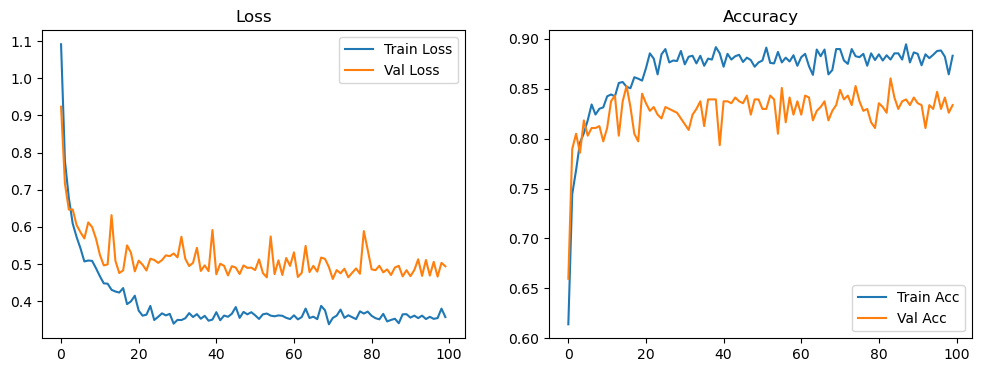

In [5]:
num_epochs = 100
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)  # Adjust LR
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Plot learning curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [6]:
# Predictions and report
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

model_path = '/home/rifat-cou/Documents/Project/Models'
Inception = os.path.join(model_path, 'InceptionResNetV2')
os.makedirs(Inception, exist_ok=True) 
# Save
torch.save(model.state_dict(), os.path.join(Inception, 'inception_resnet_v2_skin_lesion.pth'))

              precision    recall  f1-score   support

   Chikenpox       0.79      0.66      0.72       105
      Cowpox       0.95      0.92      0.93        95
     Measles       0.88      0.89      0.88       103
   MonkeyPox       0.69      0.83      0.76       101
      Normal       0.88      0.87      0.88       119

    accuracy                           0.83       523
   macro avg       0.84      0.83      0.83       523
weighted avg       0.84      0.83      0.83       523

Accuracy: 0.8337
